In [2]:
import numpy as np
import matplotlib.pyplot as plt
import gwmemory as gwm
import utils_signal as us
import importlib
importlib.reload(us)

/home/stu_brabant/Memory_effect/FT_with_GWmemory/utils_signal.py:5: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  from lal import MSUN_SI, MTSUN_SI, PC_SI, C_SI, G_SI


<module 'utils_signal' from '/home/stu_brabant/Memory_effect/FT_with_GWmemory/utils_signal.py'>

In [3]:
%pip install numpy
%pip install --no-build-isolation NRsur7dq2

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


# Computation of the Memory effect with GWMemory and FT computation

## 1. Case of the article

### Time domain computation of the memory effect with GWMemory

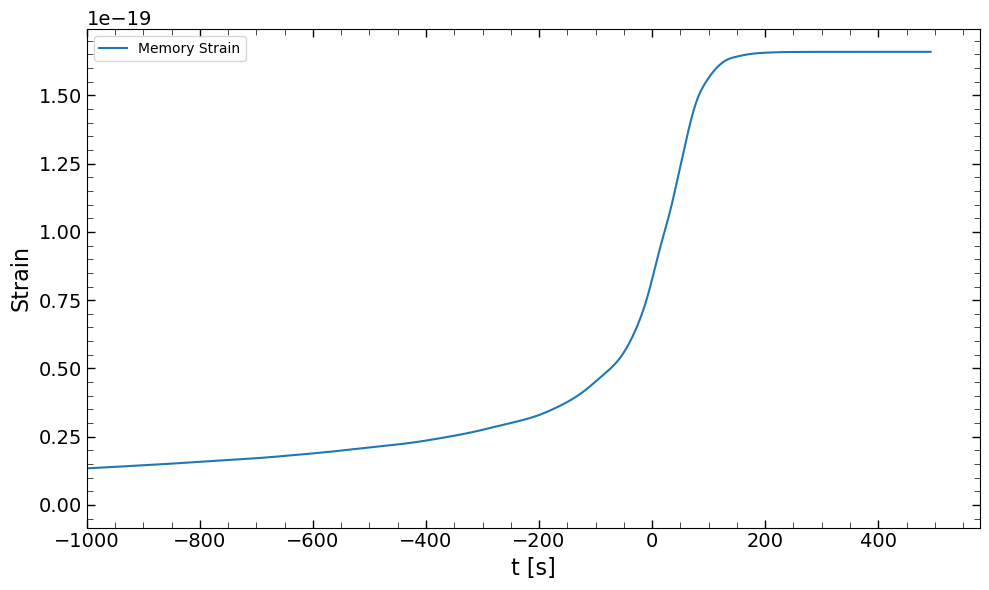

In [4]:
total_mass = 1e6
d = 6600 # distance in Mpc ~ z = 1
q = 1.0
inc = 1.047
spin_1 = [0, 0, 0]
spin_2 = [0, 0, 0]


parameters = dict(
    total_mass=total_mass,
    distance=d,
    q=q,
    inclination=inc,
    spin_1=spin_1,
    spin_2=spin_2,
    phase = 0, 
    inc=inc,
    model = 'NRSur7dq2'
)
h_mem, times_mem = gwm.time_domain_memory(**parameters)

plt.figure(figsize=(10, 6))

plt.plot(times_mem, h_mem['plus'], label='Memory Strain')
plt.xlabel('t [s]')
plt.xlim(-1000, 580)
plt.ylabel('Strain')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

### Fourier Transform of the memory effect

With the function provided by GWMemory

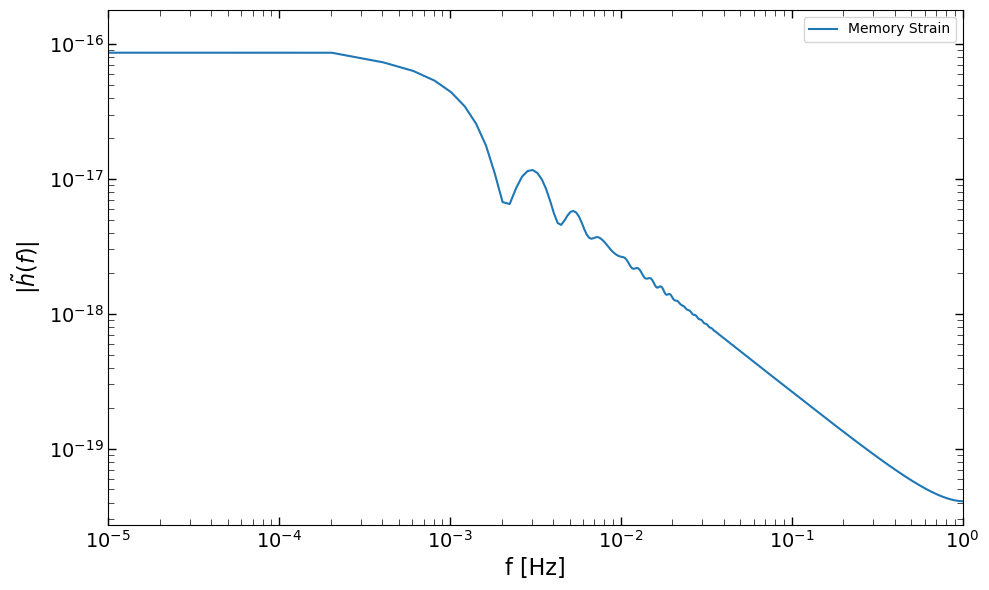

In [5]:
h_mem_init, frequencies_mem = gwm.frequency_domain_memory(**parameters)
plt.figure(figsize=(10, 6))
plt.loglog(frequencies_mem, np.abs(h_mem_init['plus']), label='Memory Strain')

plt.xlabel('f [Hz]')
plt.ylabel(r'$|\tilde{h}(f)|$')
plt.legend(loc='best')
plt.xlim(1e-5, 1e0)
plt.tight_layout()
plt.show()

With numpy's FFT, after padding and tapering the time-domain memory strain to mitigate spectral leakage 

Original dt: 0.49254909476439934, Original f_max: 1.015127233639856 Hz


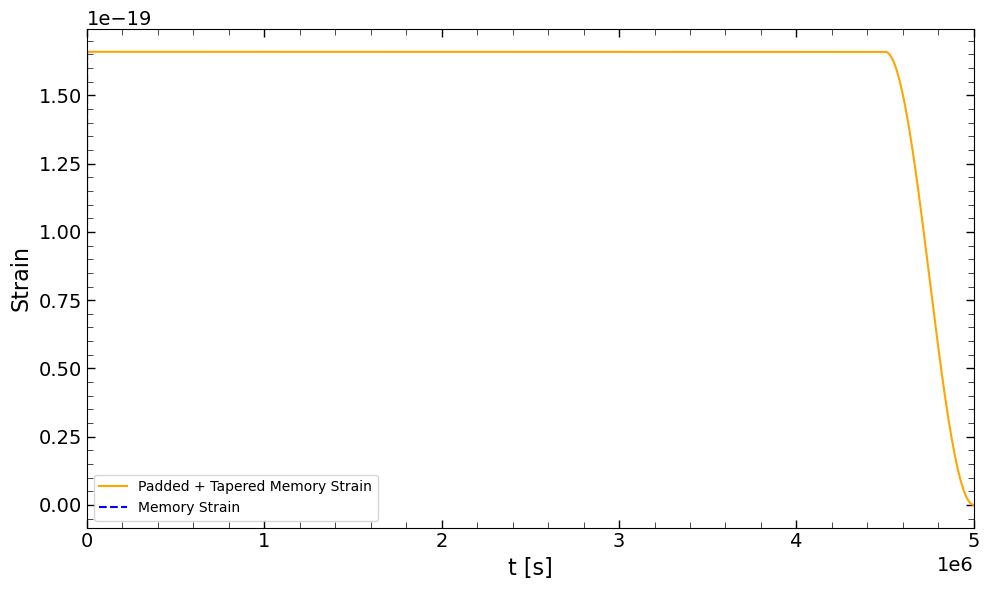

first non-zero frequency (original): 2.03e-04 Hz, FT: 2.00e-07 Hz
first non-zero frequency component (original): 8.61e-17, FT: 4.18e-14
FT of windowed + padded first 5 frequencies: [0.00000000e+00 1.99803161e-07 3.99606322e-07 5.99409484e-07
 7.99212645e-07]
FT of windowed + padded first 5 values: [ 7.88474765e-13+0.00000000e+00j -4.11328705e-14-7.62522756e-15j
 -3.80895182e-14-1.45662081e-14j -3.34244239e-14-2.02388082e-14j
 -2.76770111e-14-2.42406032e-14j]


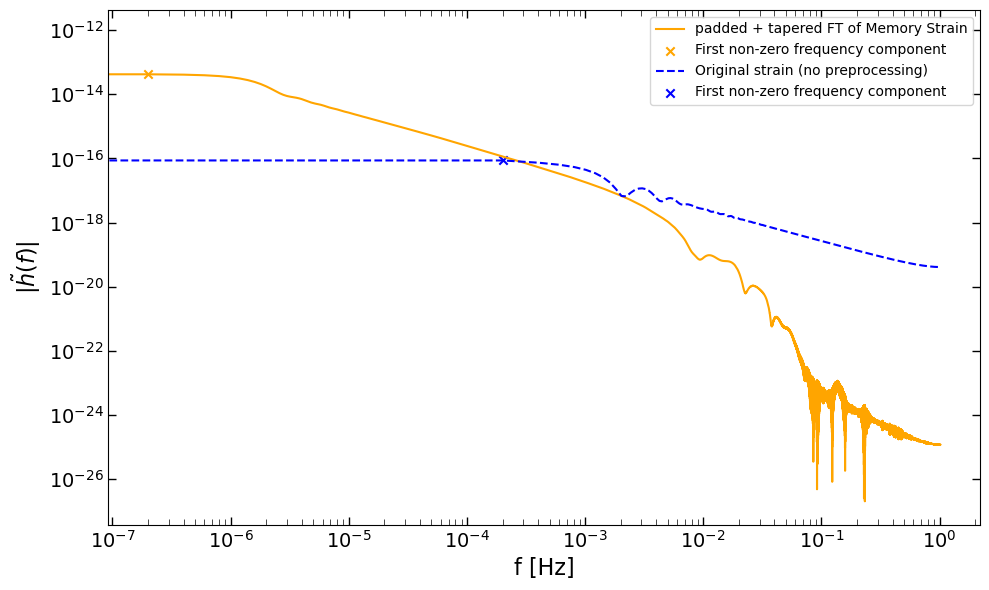

In [6]:
# try taking the FT of the time-domain memory and compute it with padding and tapering, to see if we can recover the same frequency-domain memory.
parameters = dict(
    total_mass=1e6,
    distance=d,
    q=q,
    spin_1=spin_1,
    spin_2=spin_2,
    phase = 0, 
    inc=inc,
    model = 'NRSur7dq2'
)
h_mem, times_mem = gwm.time_domain_memory(**parameters)
h_mem = h_mem['plus']
dt= times_mem[1] - times_mem[0]
print(f"Original dt: {dt}, Original f_max: {1/(2*dt)} Hz")

# Pad and taper the time-domain memory strain to mitigate spectral leakage in the FT
# The padding region is only on the right side of the signal
# This region is tapered with a turkey window with alpha = 0.1
times_padded, h_mem_windowed = us.pad_and_taper(h_mem, times_mem, 5000000, alpha = 0.1)

plt.figure(figsize=(10, 6))
plt.plot(times_padded, h_mem_windowed, label='Padded + Tapered Memory Strain', c = 'orange')
plt.plot(times_mem, h_mem, label='Memory Strain', c= 'blue', ls = '--')
plt.xlabel('t [s]')
plt.xlim(-1000, times_padded[-1]+10)
plt.ylabel('Strain')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

# Compute the FT with numpy's FFT
frequencies_ft = np.fft.rfftfreq(len(times_padded), d=times_padded[1] - times_padded[0])
h_mem_ft = np.fft.rfft(h_mem_windowed)* (times_padded[1] - times_padded[0]) # Normalize by the sampling interval to get the correct amplitude in the frequency domain
# Same was done in the function nfft of gwmemory by dividing by the sampling frequency, which is equivalent to multiplying by the sampling interval

# Plot the FT of the padded + tapered memory and compare it to the original frequency-domain memory
plt.figure(figsize=(10, 6))
plt.loglog(frequencies_ft,   np.abs(h_mem_ft), label='padded + tapered FT of Memory Strain', c = 'orange')
plt.scatter(frequencies_ft[1],np.abs(h_mem_ft[1]), c='orange', label='First non-zero frequency component', marker='x')
plt.loglog(frequencies_mem, np.abs(h_mem_init['plus']), label='Original strain (no preprocessing)', c= 'blue', ls = '--')
plt.scatter(frequencies_mem[1],  np.abs(h_mem_init['plus'][1]), c='blue', label='First non-zero frequency component', marker='x')
print(f'first non-zero frequency (original): {frequencies_mem[1]:.2e} Hz, FT: {frequencies_ft[1]:.2e} Hz')
print(f'first non-zero frequency component (original): {np.abs(h_mem_init["plus"][1]):.2e}, FT: {np.abs(h_mem_ft[1]):.2e}')

print(f"FT of windowed + padded first 5 frequencies: {frequencies_ft[:5]}")
print(f"FT of windowed + padded first 5 values: {h_mem_ft[:5]}")
plt.xlabel('f [Hz]')
plt.ylabel(r'$|\tilde{h}(f)|$')
plt.legend(loc='best')

plt.tight_layout()
plt.show()

## 2. GW170817

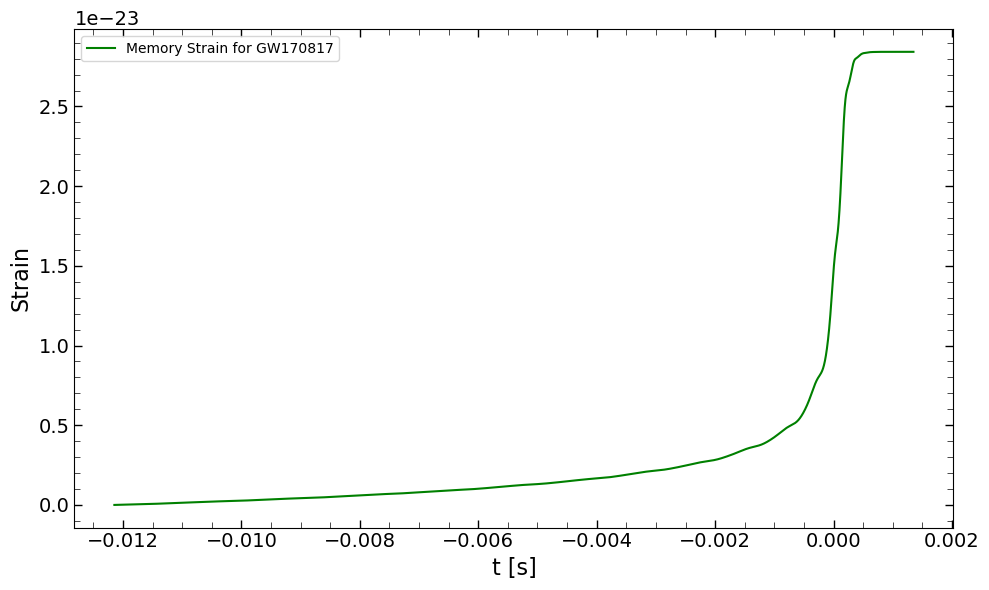

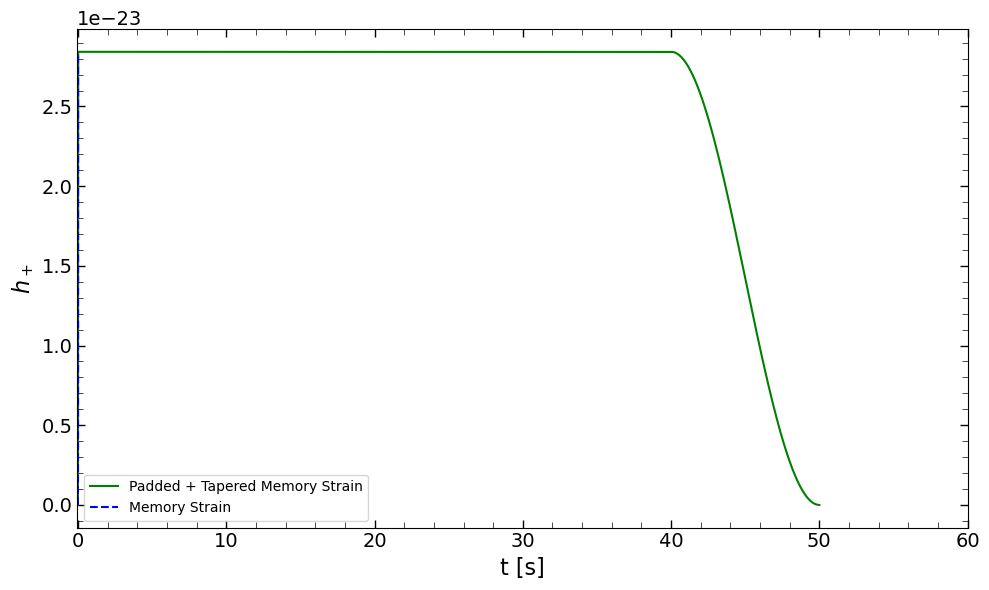

First non-zero frequency component: 2.00e-02 Hz, value: 5.51e-24


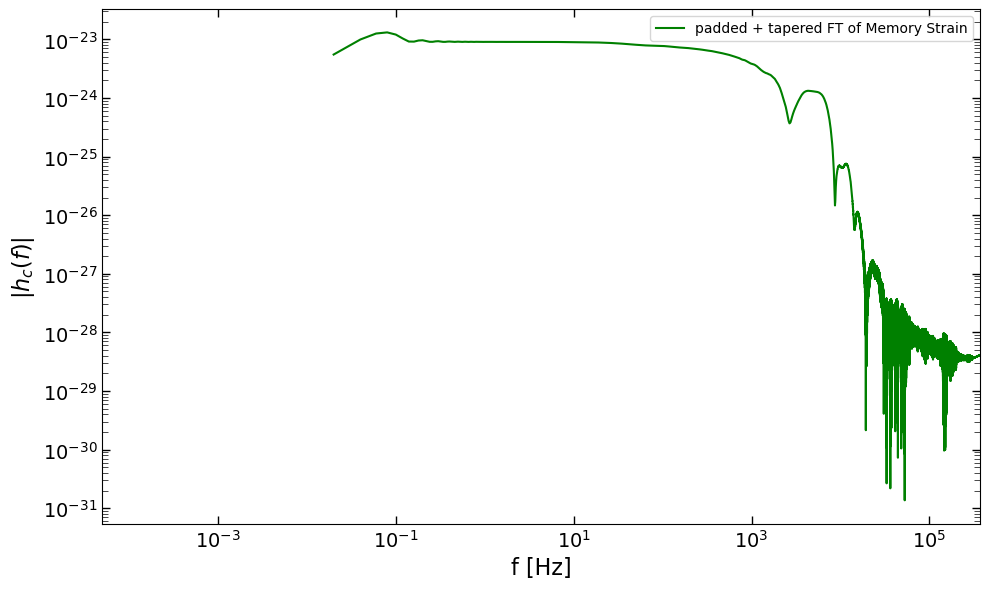

In [7]:
# Parameters for GW170817
m1 = 1.5
m2 = 1.2
q = m2/m1
parameters_170817 = dict(
        total_mass=2.74, distance=40, inc=np.radians(32), q=q, phase=0,
        spin_1=[0.0, 0.0, 0.0], spin_2=[0.0, 0.0, 0.0],
        model='NRSur7dq2'
        )
# time domain
h_mem_170817, times_mem_170817 = gwm.time_domain_memory(**parameters_170817)
h_mem_170817 = h_mem_170817['plus']
plt.figure(figsize=(10, 6))

plt.plot(times_mem_170817, h_mem_170817, label='Memory Strain for GW170817', color='green')
plt.xlabel('t [s]')

plt.ylabel('Strain')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

# frequency domain
# first pad and taper the time-domain memory 
times_padded, h_mem_windowed = us.pad_and_taper(h_mem_170817, times_mem_170817, 50, alpha = 0.2)
plt.figure(figsize=(10, 6))
plt.plot(times_padded, h_mem_windowed, label='Padded + Tapered Memory Strain', c = 'green')
plt.plot(times_mem_170817, h_mem_170817, label='Memory Strain', c= 'blue', ls = '--')
plt.xlabel('t [s]')
plt.xlim(-0.05, times_padded[-1]+10)
plt.ylabel(r'$h_+$')
plt.legend(loc='best')
plt.tight_layout()
plt.show()
# Compute FT 
frequencies_ft = np.fft.rfftfreq(len(times_padded), d=times_padded[1] - times_padded[0])
h_mem_ft = np.fft.rfft(h_mem_windowed)* (times_padded[1] - times_padded[0])
# We plot the frequency after the first non-zero fequency 
# Its value is much smaller than the other and does not follow the same trend as the other low frequencies, which is why we ignore it in the plot
plt.figure(figsize=(10, 6))
plt.loglog(frequencies_ft[1:], 2* frequencies_ft[1:] * np.abs(h_mem_ft[1:]), label='padded + tapered FT of Memory Strain', c = 'green')
plt.xlabel('f [Hz]')
plt.ylabel(r'$|h_c(f)|$')
plt.legend(loc='best')
plt.xlim(5e-5, frequencies_ft.max())
print(f"First non-zero frequency component: {frequencies_ft[1]:.2e} Hz, value: {2* frequencies_ft[1] * np.abs(h_mem_ft[1]):.2e}")
plt.tight_layout()
plt.show()


OK we retrieve the memory effect amplitude ~ 1e-23 for low frequencies and then a drop at higher frequencies for the caracteristic strain.\\

The impact of the padding (length) and tapering (type of window - alpha parameter - ...) should be more investigated to see how it affects the FT of the memory effect. Maybe add a chapter on this in the report before the linear memory effect chapter ? Also the impact of the approximant used 